In [17]:
import torch
import omegaconf
import typing

In [22]:
ckpt = torch.load("../checkpoints/ft-transformer-gate-residuals/best_model/last.ckpt", map_location="cpu", weights_only=False)


In [57]:
state_dict = ckpt["state_dict"]

# 2. 'net.'으로 시작하는 진짜 파라미터만 골라내기
pure_net_state_dict = {}
for key, value in state_dict.items():
    if key.startswith("net."):
        new_key = key.replace("net.", "", 1) # 'net.layer1.weight' -> 'layer1.weight'
        pure_net_state_dict[new_key] = value
    print(key)

net.cls_token
net.backbone_net.self_blocks.0.attn.q_proj.weight
net.backbone_net.self_blocks.0.attn.k_proj.weight
net.backbone_net.self_blocks.0.attn.v_proj.weight
net.backbone_net.self_blocks.0.attn.out_proj.weight
net.backbone_net.self_blocks.0.ffn.w1.weight
net.backbone_net.self_blocks.0.ffn.w2.weight
net.backbone_net.self_blocks.0.ffn.w3.weight
net.backbone_net.self_blocks.0.attn_ln.weight
net.backbone_net.self_blocks.0.ffn_ln.weight
net.backbone_net.self_blocks.1.attn.q_proj.weight
net.backbone_net.self_blocks.1.attn.k_proj.weight
net.backbone_net.self_blocks.1.attn.v_proj.weight
net.backbone_net.self_blocks.1.attn.out_proj.weight
net.backbone_net.self_blocks.1.ffn.w1.weight
net.backbone_net.self_blocks.1.ffn.w2.weight
net.backbone_net.self_blocks.1.ffn.w3.weight
net.backbone_net.self_blocks.1.attn_ln.weight
net.backbone_net.self_blocks.1.ffn_ln.weight
net.backbone_net.self_blocks.2.attn.q_proj.weight
net.backbone_net.self_blocks.2.attn.k_proj.weight
net.backbone_net.self_blocks.2

In [49]:
pure_net_state_dict["backbone_net.self_blocks.0.attn.q_proj.weight"]

tensor([[ 0.0028,  0.0381,  0.0020,  ..., -0.0677, -0.0868, -0.0044],
        [-0.1271, -0.0200, -0.0406,  ...,  0.0307, -0.2236,  0.0058],
        [-0.0875, -0.0111, -0.0081,  ...,  0.0624, -0.0540,  0.0106],
        ...,
        [ 0.0227,  0.0609,  0.0314,  ...,  0.0019, -0.0471, -0.0547],
        [ 0.0771,  0.0557,  0.1468,  ..., -0.0262,  0.0569, -0.0033],
        [-0.1024, -0.1162, -0.1219,  ...,  0.0738, -0.0066, -0.0239]])

In [53]:
state_dict.keys()
state_dict["tokenizer.num_feature_identifier"]

tensor([[[-3.3349e-03,  3.9255e-02,  2.6797e-03, -9.8752e-03, -3.5444e-03,
          -2.4263e-03,  3.4989e-02, -1.6812e-03, -3.8211e-02,  1.9542e-02,
          -5.0881e-02, -1.2393e-03, -3.4650e-02,  1.4796e-02, -8.4698e-04,
           2.5029e-02,  5.7117e-02, -2.4310e-02,  8.5376e-03,  9.7436e-03,
          -3.3859e-02, -2.4282e-02, -3.2670e-02, -3.0970e-02, -6.0131e-02,
          -4.7940e-02,  4.1435e-02, -5.4533e-02, -3.3344e-03, -3.3933e-02,
          -1.7921e-02, -1.7545e-02,  4.7556e-02, -3.7737e-02, -7.1323e-02,
          -9.1225e-03, -1.2715e-02, -2.6095e-02, -3.5349e-02, -2.7426e-02,
          -2.0214e-02,  2.1151e-02, -3.9529e-02, -2.0036e-02, -3.2451e-02,
           8.9913e-03, -1.7852e-02, -5.8298e-02, -2.2405e-03, -5.5422e-04,
           6.4311e-03, -1.0043e-02, -1.3293e-02,  1.3658e-02,  2.8884e-03,
           4.3617e-02, -5.6012e-03, -1.8589e-02, -2.1725e-02, -1.8753e-02,
           6.9492e-03, -1.3220e-02, -2.4188e-02,  6.3122e-03],
         [-1.3357e-02, -9.0875e-04,  

In [27]:
# 모델의 모든 파라미터 이름과 형태 출력
for name, param in pure_net_state_dict.items():
    print(f"Layer: {name} | Shape: {param.shape}")

Layer: cls_token | Shape: torch.Size([1, 1, 64])
Layer: backbone_net.self_blocks.0.attn.q_proj.weight | Shape: torch.Size([64, 64])
Layer: backbone_net.self_blocks.0.attn.k_proj.weight | Shape: torch.Size([64, 64])
Layer: backbone_net.self_blocks.0.attn.v_proj.weight | Shape: torch.Size([64, 64])
Layer: backbone_net.self_blocks.0.attn.out_proj.weight | Shape: torch.Size([64, 64])
Layer: backbone_net.self_blocks.0.ffn.w1.weight | Shape: torch.Size([170, 64])
Layer: backbone_net.self_blocks.0.ffn.w2.weight | Shape: torch.Size([170, 64])
Layer: backbone_net.self_blocks.0.ffn.w3.weight | Shape: torch.Size([64, 170])
Layer: backbone_net.self_blocks.0.attn_ln.weight | Shape: torch.Size([64])
Layer: backbone_net.self_blocks.0.ffn_ln.weight | Shape: torch.Size([64])
Layer: backbone_net.self_blocks.1.attn.q_proj.weight | Shape: torch.Size([64, 64])
Layer: backbone_net.self_blocks.1.attn.k_proj.weight | Shape: torch.Size([64, 64])
Layer: backbone_net.self_blocks.1.attn.v_proj.weight | Shape: tor

In [58]:
latent_tokens = state_dict["net.backbone_net.intersample_blocks.0.latents"]

In [59]:
latent_tokens

tensor([[[ 0.0970,  0.0735,  0.0257,  ..., -0.0656, -0.0216,  0.0290],
         [-0.0310,  0.0802,  0.0663,  ..., -0.0072,  0.1351,  0.0718],
         [ 0.0071,  0.0292,  0.0026,  ...,  0.0822, -0.0225,  0.0179],
         ...,
         [ 0.0006,  0.0348, -0.0068,  ...,  0.0285,  0.0623,  0.0095],
         [ 0.0263,  0.0269,  0.0145,  ...,  0.0079, -0.0714,  0.0389],
         [ 0.0644,  0.0361,  0.0258,  ...,  0.0509,  0.0557,  0.0401]],

        [[ 0.0417, -0.0791,  0.0435,  ...,  0.0183,  0.0047,  0.0399],
         [-0.0329, -0.0323,  0.0660,  ..., -0.0633,  0.0272, -0.0343],
         [ 0.1028, -0.0157, -0.0079,  ..., -0.0883, -0.0336,  0.0753],
         ...,
         [-0.0536, -0.0622, -0.0280,  ...,  0.0958,  0.0807,  0.0873],
         [-0.1130, -0.0822,  0.0896,  ...,  0.0657,  0.0031, -0.0651],
         [ 0.0011, -0.0313, -0.0100,  ...,  0.0600, -0.0402,  0.0869]],

        [[ 0.1097,  0.0152,  0.0186,  ..., -0.0166,  0.0681, -0.0574],
         [-0.0824, -0.0300,  0.0560,  ..., -0

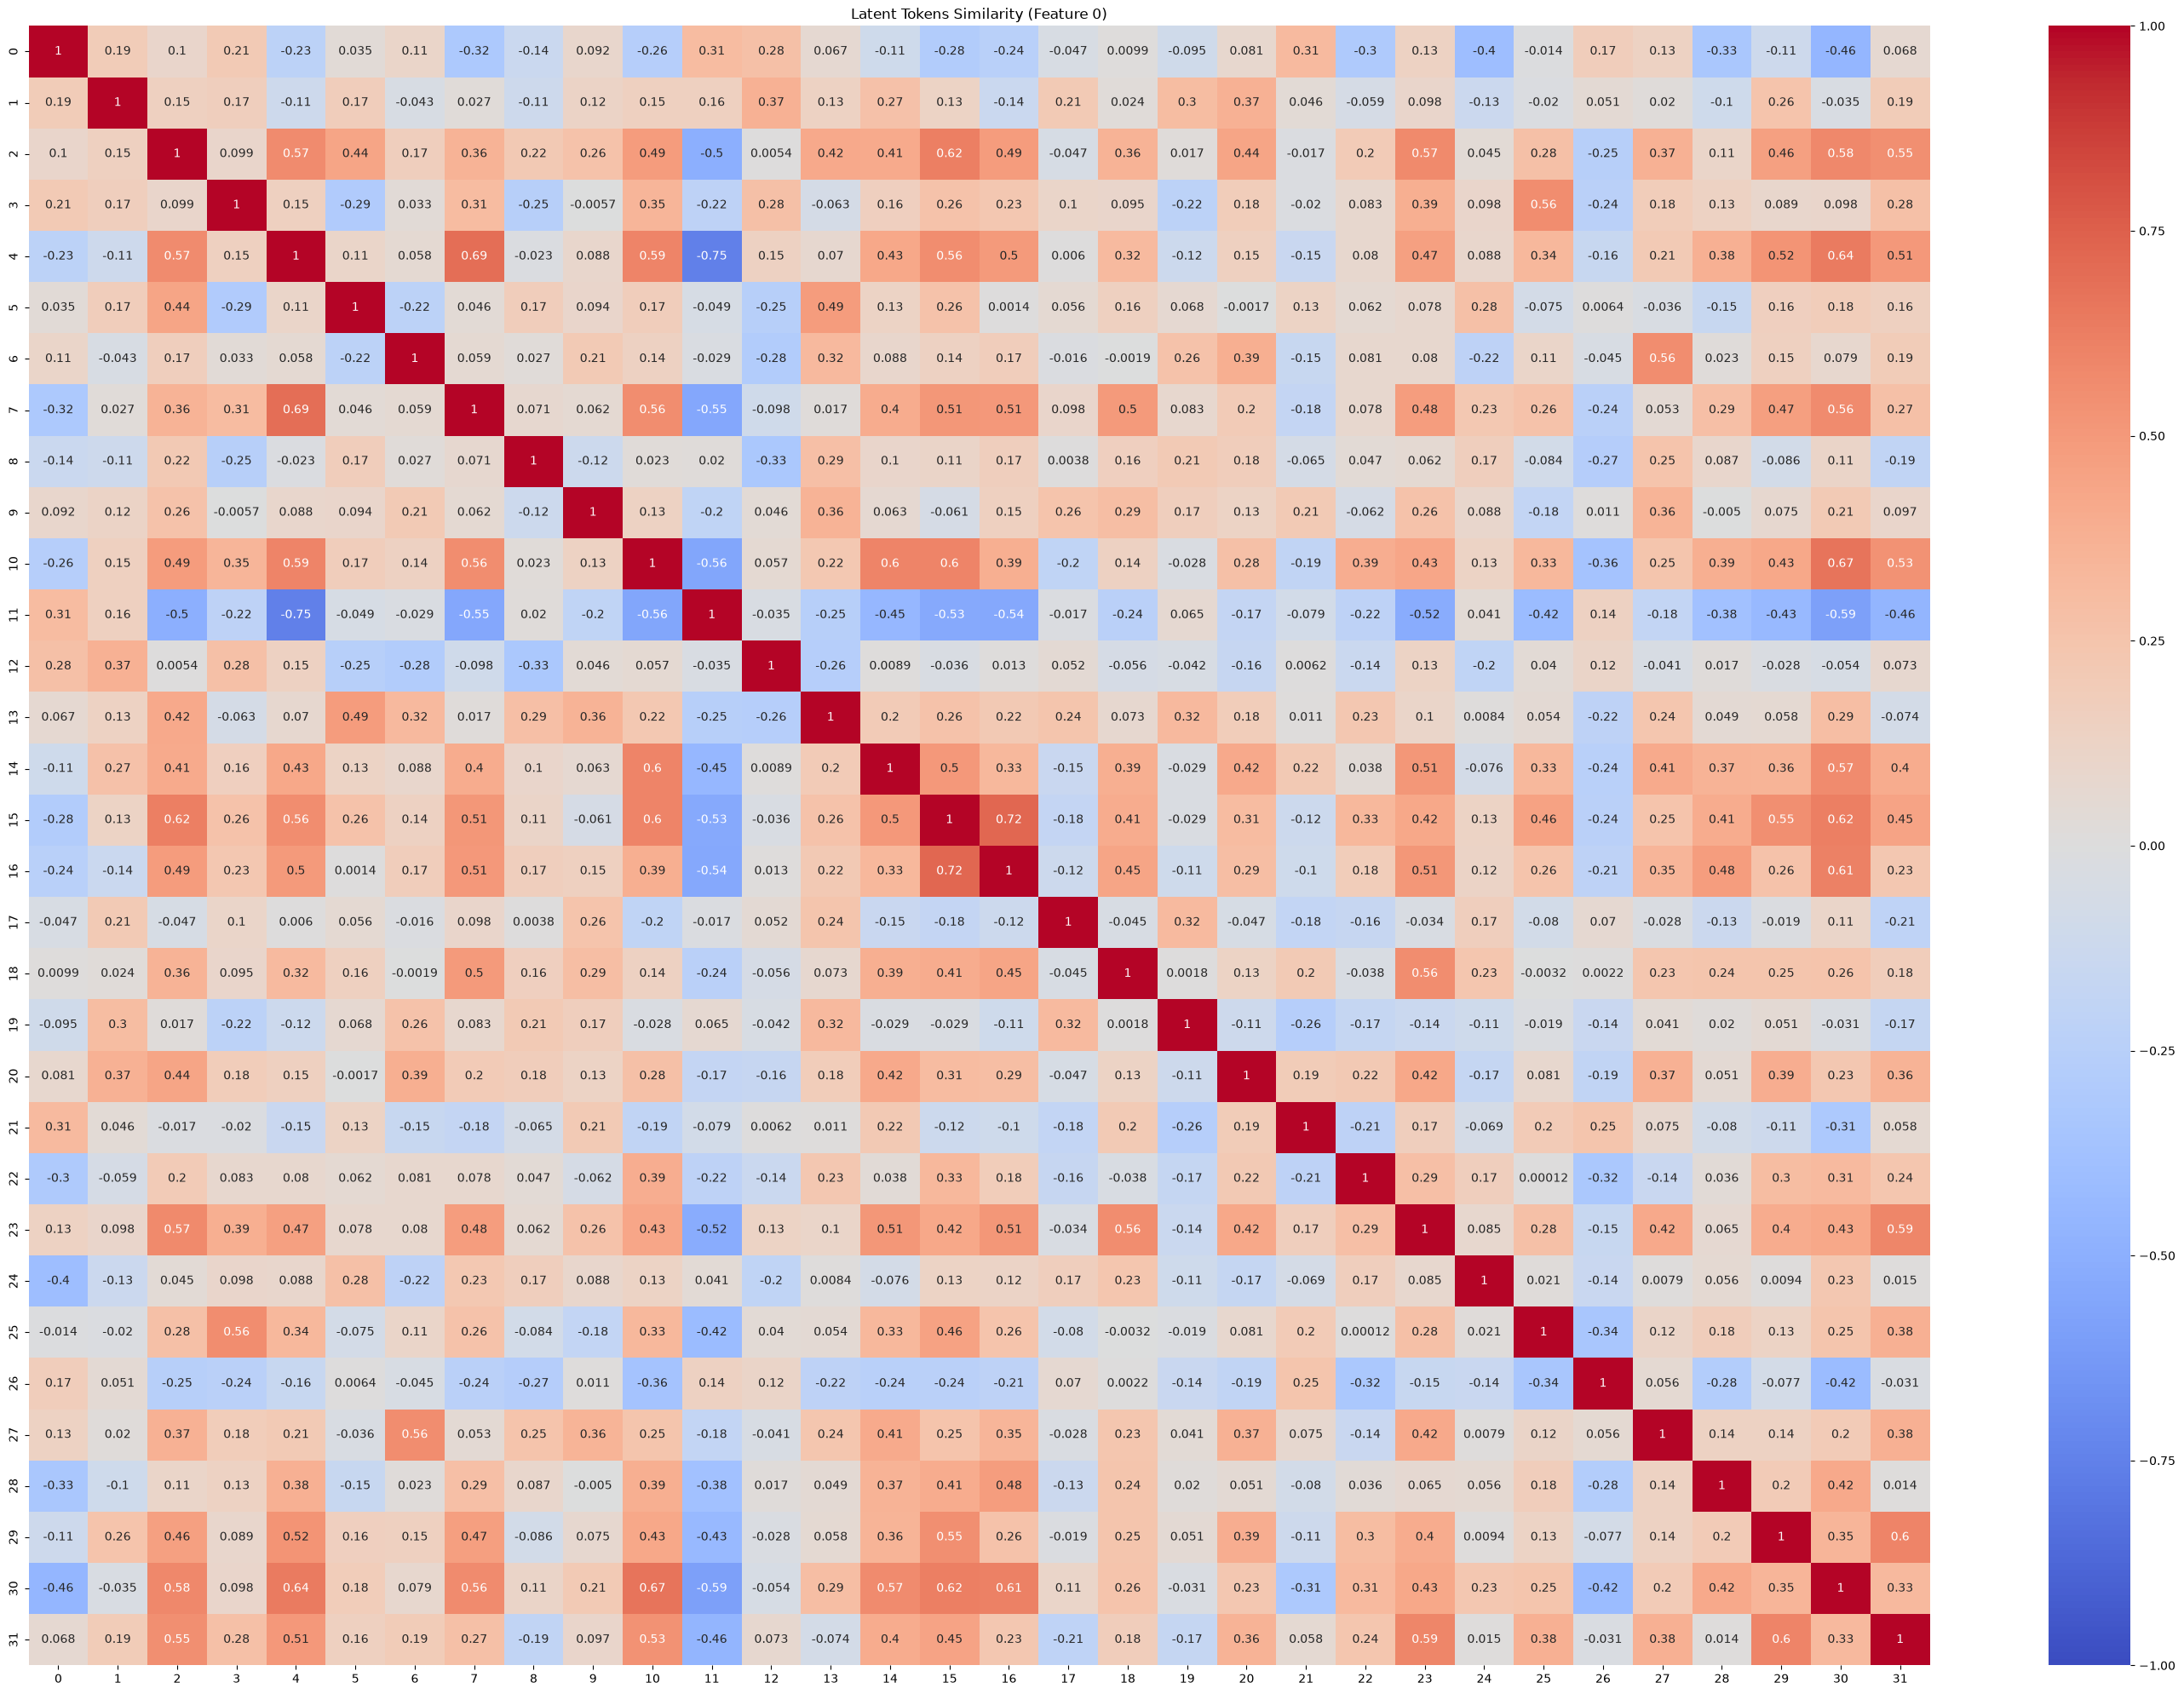

In [74]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

ckpt = torch.load("../checkpoints/ft-transformer-gate-residuals/best_model/last-v7.ckpt", map_location="cpu", weights_only=False)

# 1. 체크포인트에서 latents 가중치 빼오기
state_dict = ckpt["state_dict"]

# net.backbone_net.intersample_blocks.0.latents 형태의 Key를 찾습니다
latent_key = [k for k in state_dict.keys() if 'intersample_blocks.0.latents' in k][0]
latents_tensor = state_dict[latent_key] 
# Shape: (num_features, num_latent_tokens, d_latent)

# 2. 첫 번째 변수(Feature 0)의 토큰 간 코사인 유사도 시각화 (토큰 붕괴 확인)
feature_0_latents = latents_tensor[0] # (num_latent_tokens, d_latent)

# 정규화 후 행렬 곱 = 코사인 유사도
normed_latents = torch.nn.functional.normalize(feature_0_latents, p=2, dim=-1)
similarity_matrix = torch.matmul(normed_latents, normed_latents.T)

# 히트맵 그리기
plt.figure(figsize=(36,25))
sns.heatmap(similarity_matrix.numpy(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Latent Tokens Similarity (Feature 0)")
plt.show()

tensor([0.2842])